In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report,
)
from pathlib import Path

In [3]:
EMBEDDINGS_DIR = Path("embeddings")

resnetdf = pd.read_csv(EMBEDDINGS_DIR / "resnet50_embeddings.csv")
efnetdf  = pd.read_csv(EMBEDDINGS_DIR / "efficientnet_b4_embeddings.csv")

print(f"resnetdf : {resnetdf.shape}")
print(f"efnetdf  : {efnetdf.shape}")

resnetdf : (1506, 2050)
efnetdf  : (1506, 1794)


# Choix du modèle à utiliser pour le clustering

In [4]:
df = efnetdf.copy()
modele = "EfficientNet-B4"

# Separation Train Test


In [5]:
test_df   = df[df["label"].isin([0, 1])] 
train_df = df[df["label"]==-1]
X=train_df.drop(columns=["label", "image_path"])

# Standardisation

In [6]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.shape

(1406, 1792)

# PCA

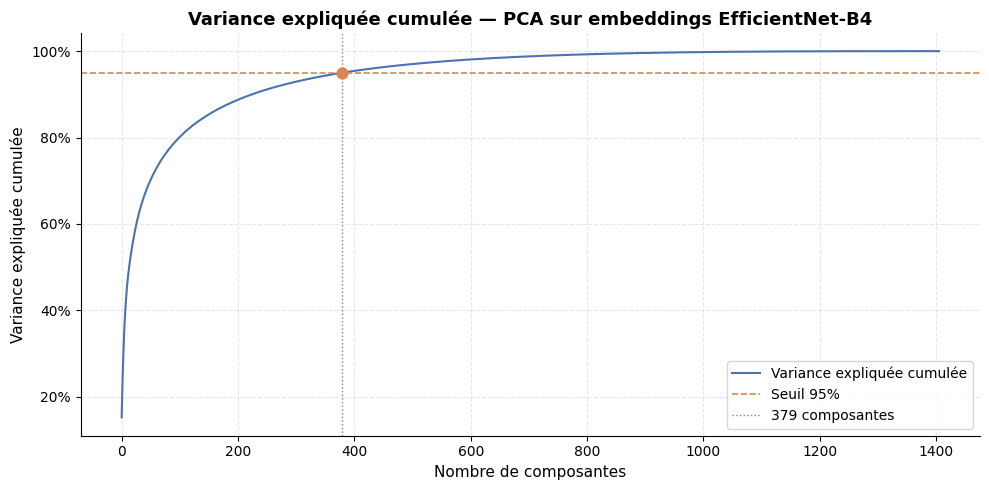

379 dimensions à garder pour conserver 95% de la variance


In [7]:
pcamodel = PCA(n_components=min(X_scaled.shape), random_state=42)
pcamodel.fit(X_scaled)

cumvar = np.cumsum(pcamodel.explained_variance_ratio_)
dim = np.argmax(cumvar > 0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cumvar, color="#4C72B0", linewidth=1.5, label="Variance expliquée cumulée")
ax.axhline(0.95, color="#DD8452", linewidth=1.2, linestyle="--", label="Seuil 95%")
ax.axvline(dim, color="gray", linewidth=1, linestyle=":", label=f"{dim} composantes")
ax.scatter([dim], [cumvar[dim]], color="#DD8452", zorder=5, s=60)

ax.set_title(f"Variance expliquée cumulée — PCA sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composantes", fontsize=11)
ax.set_ylabel("Variance expliquée cumulée", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"{dim} dimensions à garder pour conserver 95% de la variance")

In [8]:
pcamodel = PCA(n_components=dim)
pcamodel.fit(X_scaled)
X_pca = pcamodel.transform(X_scaled)
X_pca.shape

(1406, 379)

# Étude du meilleur k (BIC / AIC)

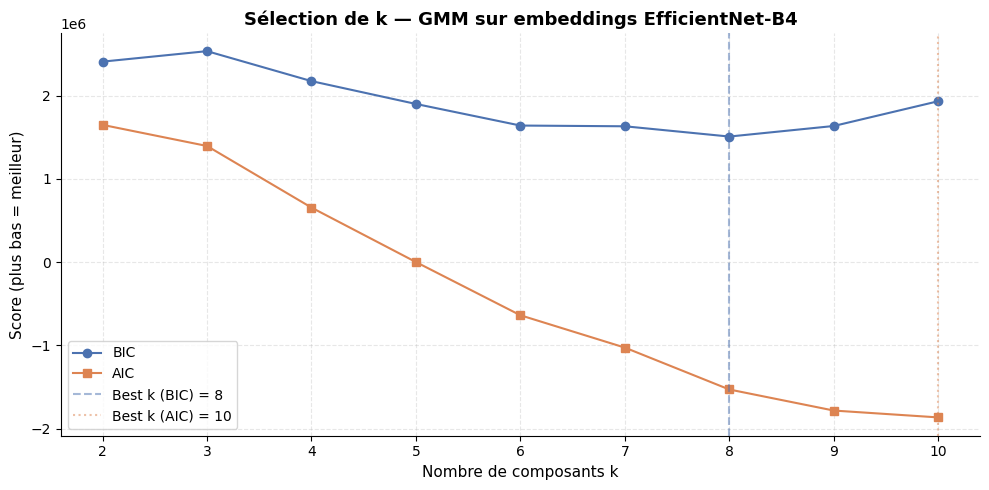

Best k via BIC : 8  (BIC=1509691.0)
Best k via AIC : 10  (AIC=-1865258.2)


In [9]:
# ── BIC / AIC sweep : choix du meilleur k ─────────────────────────────────
k_range = list(range(2, 11))
bic_scores = []
aic_scores = []

for k in k_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm_k.fit(X_pca)
    bic_scores.append(gmm_k.bic(X_pca))
    aic_scores.append(gmm_k.aic(X_pca))

best_k_bic = k_range[int(np.argmin(bic_scores))]
best_k_aic = k_range[int(np.argmin(aic_scores))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, bic_scores, marker="o", color="#4C72B0", linewidth=1.5, label="BIC")
ax.plot(k_range, aic_scores, marker="s", color="#DD8452", linewidth=1.5, label="AIC")
ax.axvline(best_k_bic, color="#4C72B0", linestyle="--", alpha=0.5, label=f"Best k (BIC) = {best_k_bic}")
ax.axvline(best_k_aic, color="#DD8452", linestyle=":",  alpha=0.5, label=f"Best k (AIC) = {best_k_aic}")
ax.set_title(f"Sélection de k — GMM sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composants k", fontsize=11)
ax.set_ylabel("Score (plus bas = meilleur)", fontsize=11)
ax.set_xticks(k_range)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Best k via BIC : {best_k_bic}  (BIC={min(bic_scores):.1f})")
print(f"Best k via AIC : {best_k_aic}  (AIC={min(aic_scores):.1f})")

# Clustering

In [10]:
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)

In [11]:
gmm.fit(X_pca)
cluster_labels = gmm.predict(X_pca)

In [12]:
# Add cluster labels back to train_df
train_df = train_df.copy()
train_df["cluster"] = cluster_labels

In [13]:
# ── Re-fit GMM (k=2) avec config saine ────────────────────────────────────
# Le fit initial (covariance_type="full", n_init=1) était dégénéré (3 iter, matrices singulières).
# On overwrite `gmm`, `cluster_labels` et train_df["cluster"] pour que la suite (SCORES, exports)
# s'appuie sur un modèle fiable.
gmm = GaussianMixture(
    n_components=2,
    covariance_type="tied",
    reg_covar=1e-2,
    n_init=10,
    random_state=42,
)
gmm.fit(X_pca)
cluster_labels = gmm.predict(X_pca)

train_df = train_df.copy()
train_df["cluster"] = cluster_labels

# Diagnostic rapide train vs test
X_test_chk     = test_df.drop(columns=["label", "image_path"])
X_test_scaled_chk = pd.DataFrame(scaler.transform(X_test_chk), columns=X.columns)
X_test_pca_chk    = pcamodel.transform(X_test_scaled_chk)

sil2 = silhouette_score(X_pca, cluster_labels)
print(f"Silhouette (k=2) : {sil2:.4f}")
print(f"BIC (k=2)        : {gmm.bic(X_pca):.1f}")
print(f"AIC (k=2)        : {gmm.aic(X_pca):.1f}")
print(f"Converged        : {gmm.converged_}  (itérations : {gmm.n_iter_})")
print(f"\nRépartition train : {np.bincount(cluster_labels, minlength=2)}")
print(f"Répartition test  : {np.bincount(gmm.predict(X_test_pca_chk), minlength=2)}")
print(f"\nLL train : {gmm.score_samples(X_pca).mean():.1f}")
print(f"LL test  : {gmm.score_samples(X_test_pca_chk).mean():.1f}  (gap < 100 = sain)")

Silhouette (k=2) : 0.1159
BIC (k=2)        : 2241563.2
AIC (k=2)        : 1859634.8
Converged        : True  (itérations : 7)

Répartition train : [625 781]
Répartition test  : [64 36]

LL train : -609.6
LL test  : -585.2  (gap < 100 = sain)


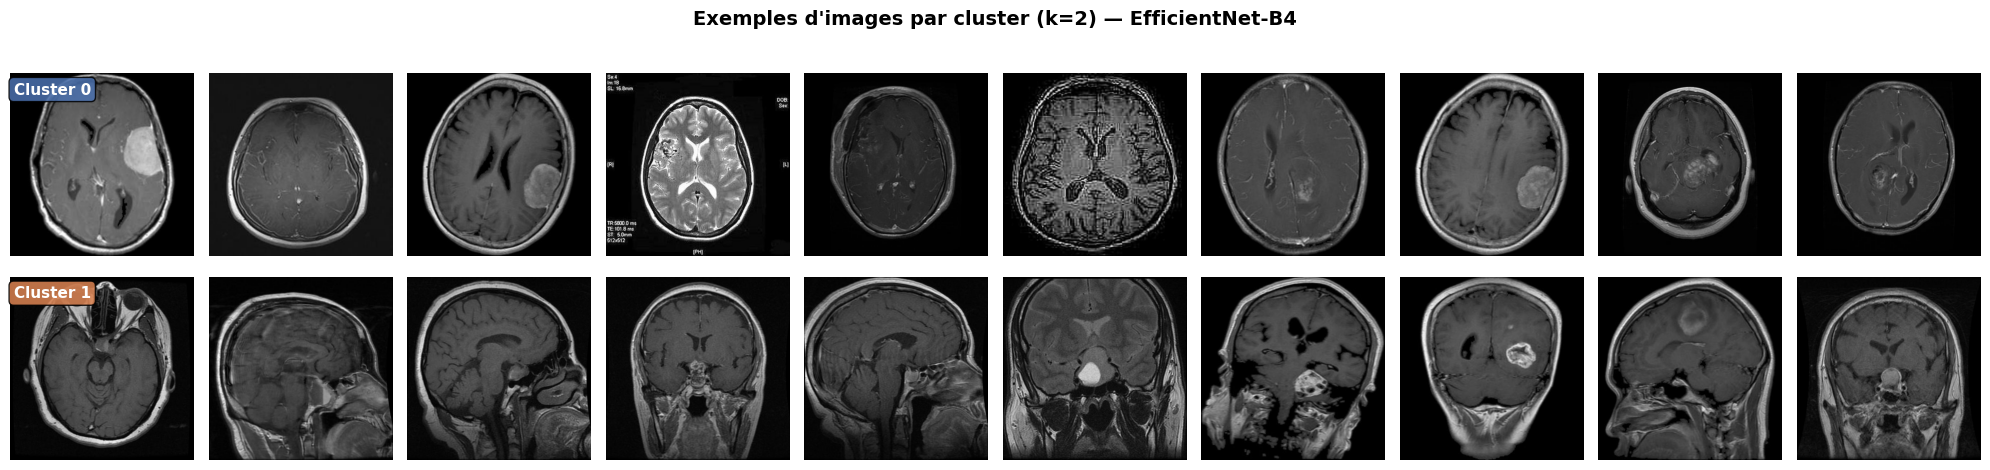

In [14]:
from PIL import Image

CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}
n_samples = 10
clusters = [0, 1]
fig, axes = plt.subplots(len(clusters), n_samples, figsize=(20, 5))
fig.suptitle(f"Exemples d'images par cluster (k=2) — {modele}", fontsize=14, fontweight="bold")

for row_idx, cluster_id in enumerate(clusters):
    available = train_df[train_df["cluster"] == cluster_id]["image_path"]
    sample_paths = available.sample(min(n_samples, len(available)), random_state=21).tolist()
    for col_idx in range(n_samples):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_paths):
            with Image.open(sample_paths[col_idx]) as img:
                ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id}",
        transform=axes[row_idx][0].transAxes,
        fontsize=11, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

In [15]:
sil = silhouette_score(X_pca, cluster_labels)
bic = gmm.bic(X_pca)
aic = gmm.aic(X_pca)

print(f"Silhouette : {sil:.4f}  (plus proche de 1 = meilleur)")
print(f"BIC        : {bic:.1f}  (plus bas = meilleur)")
print(f"AIC        : {aic:.1f}  (plus bas = meilleur)")
print(f"Converged  : {gmm.converged_}  (itérations : {gmm.n_iter_})")

Silhouette : 0.1159  (plus proche de 1 = meilleur)
BIC        : 2241563.2  (plus bas = meilleur)
AIC        : 1859634.8  (plus bas = meilleur)
Converged  : True  (itérations : 7)


# Visualisation

In [16]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

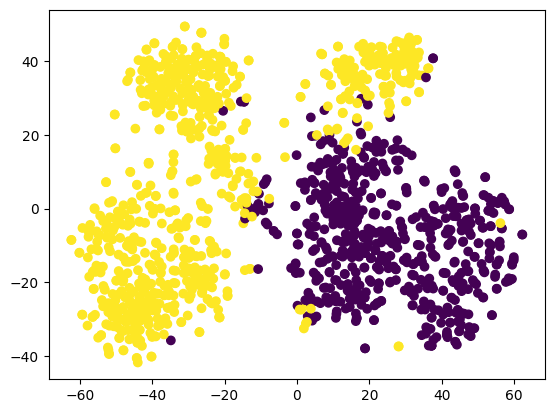

In [17]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels)

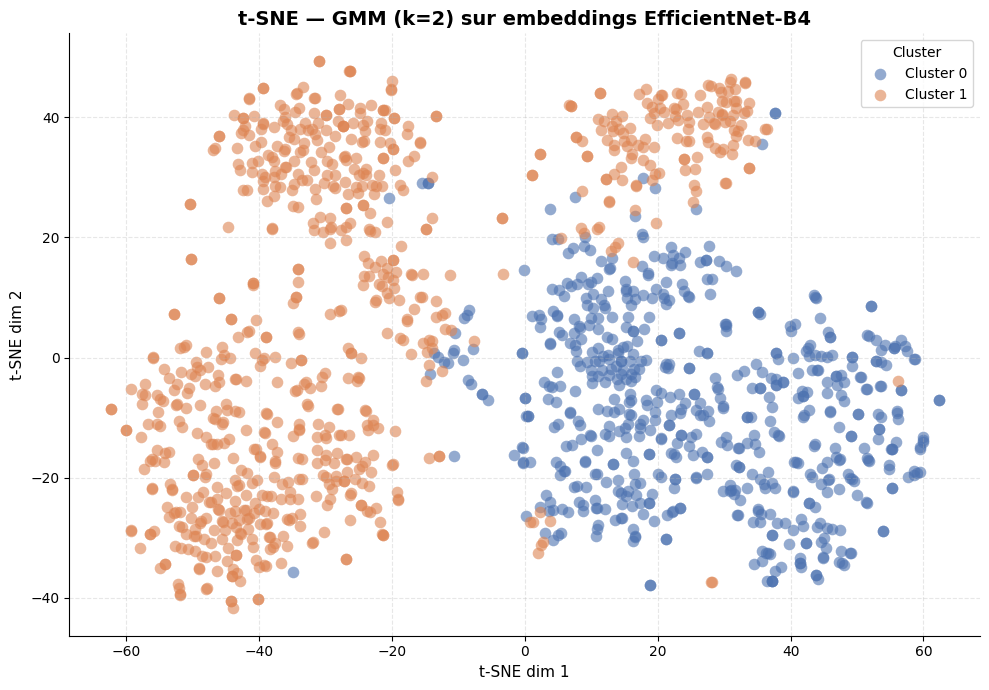

In [18]:
CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}",
        alpha=0.6, s=70, linewidths=0,
    )

ax.set_title(f"t-SNE — GMM (k=2) sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

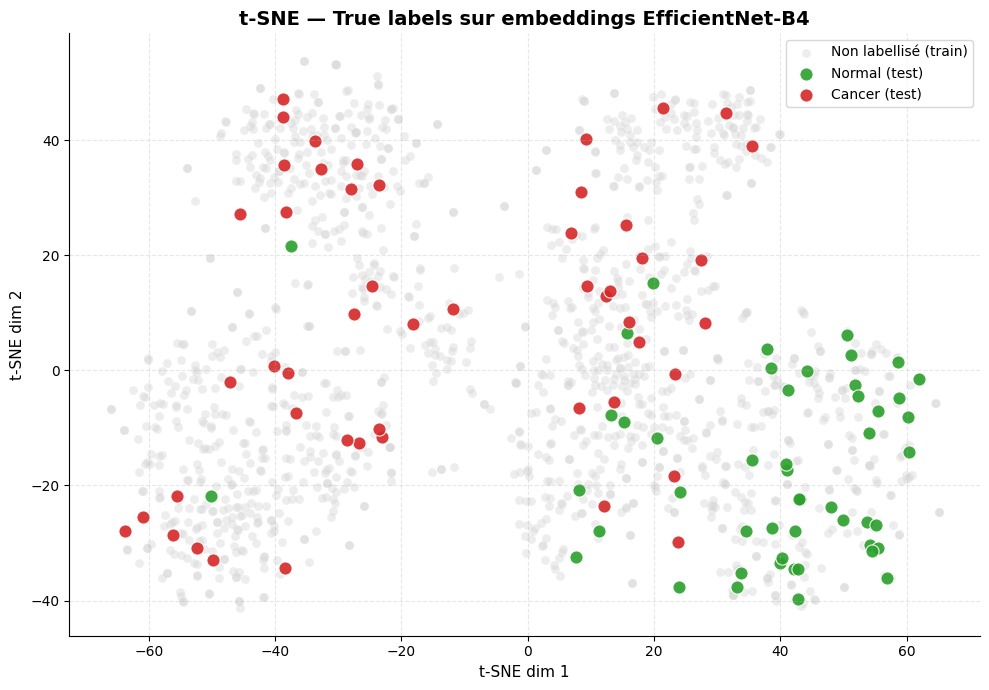

In [19]:
# ── t-SNE avec true labels (train+test combinés) ──────────────────────────
X_test_all     = test_df.drop(columns=["label", "image_path"])
X_test_scaled_ = pd.DataFrame(scaler.transform(X_test_all), columns=X.columns)
X_test_pca_    = pcamodel.transform(X_test_scaled_)

X_combined = np.vstack([X_pca, X_test_pca_])
n_train    = X_pca.shape[0]

tsne_combined = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_comb   = tsne_combined.fit_transform(X_combined)

X_tsne_train = X_tsne_comb[:n_train]
X_tsne_test  = X_tsne_comb[n_train:]
y_test       = test_df["label"].values  # 0=normal, 1=cancer

LABEL_COLORS = {0: "#2CA02C", 1: "#D62728"}  # vert=normal, rouge=cancer
LABEL_NAMES  = {0: "Normal", 1: "Cancer"}

fig, ax = plt.subplots(figsize=(10, 7))

# Fond : images non labellisées (train)
ax.scatter(
    X_tsne_train[:, 0], X_tsne_train[:, 1],
    c="lightgray", label="Non labellisé (train)",
    alpha=0.4, s=40, linewidths=0,
)

# Superposition : test avec true labels
for lbl, color in LABEL_COLORS.items():
    mask = y_test == lbl
    ax.scatter(
        X_tsne_test[mask, 0], X_tsne_test[mask, 1],
        c=color, label=f"{LABEL_NAMES[lbl]} (test)",
        alpha=0.9, s=90, linewidths=0.8, edgecolors="white",
    )

ax.set_title(f"t-SNE — True labels sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# GMM avec k=4

Les 4 blobs observés sur la t-SNE ci-dessus suggèrent une structure plus fine. On refit GMM avec `k=4` et on compare visuellement.

In [20]:
# ── Fit GMM avec k=4 ──────────────────────────────────────────────────────
# covariance_type="tied"  : 1 seule Σ 379×379 partagée entre les 4 clusters
#                           → orientation oblique conservée (contrairement à "diag")
#                           → Σ fittée sur 1406 points au lieu de 158 (le plus petit cluster)
# reg_covar=1e-2          : régularisation λI
# n_init=10               : multi-démarrage
gmm4 = GaussianMixture(
    n_components=4,
    covariance_type="tied",
    reg_covar=1e-2,
    n_init=10,
    random_state=42,
)
gmm4.fit(X_pca)
cluster_labels_4 = gmm4.predict(X_pca)

train_df = train_df.copy()
train_df["cluster4"] = cluster_labels_4

sil4 = silhouette_score(X_pca, cluster_labels_4)
bic4 = gmm4.bic(X_pca)
aic4 = gmm4.aic(X_pca)

print(f"Silhouette (k=4) : {sil4:.4f}")
print(f"BIC (k=4)        : {bic4:.1f}")
print(f"AIC (k=4)        : {aic4:.1f}")
print(f"Converged        : {gmm4.converged_}  (itérations : {gmm4.n_iter_})")
print(f"\nRépartition des clusters :")
print(pd.Series(cluster_labels_4).value_counts().sort_index().rename("count"))

Silhouette (k=4) : 0.1270
BIC (k=4)        : 2240045.8
AIC (k=4)        : 1854128.5
Converged        : True  (itérations : 6)

Répartition des clusters :
0    628
1    256
2    369
3    153
Name: count, dtype: int64


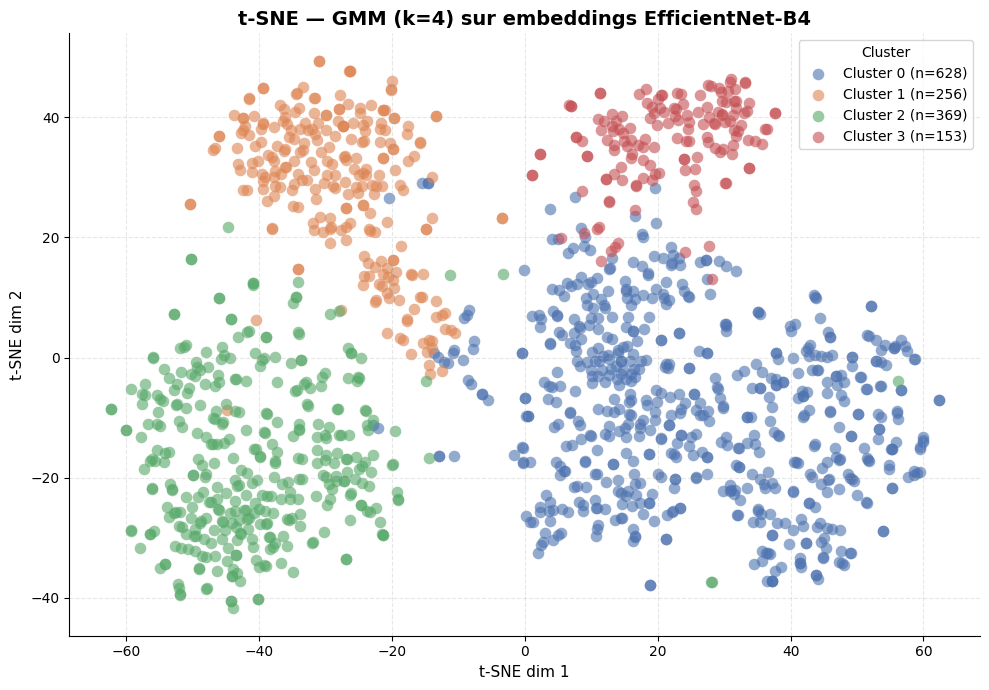

In [21]:
# ── t-SNE coloré par clusters k=4 ─────────────────────────────────────────
CLUSTER_COLORS_4 = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868", 3: "#C44E52"}

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id, color in CLUSTER_COLORS_4.items():
    mask = cluster_labels_4 == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id} (n={mask.sum()})",
        alpha=0.6, s=70, linewidths=0,
    )

ax.set_title(f"t-SNE — GMM (k=4) sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

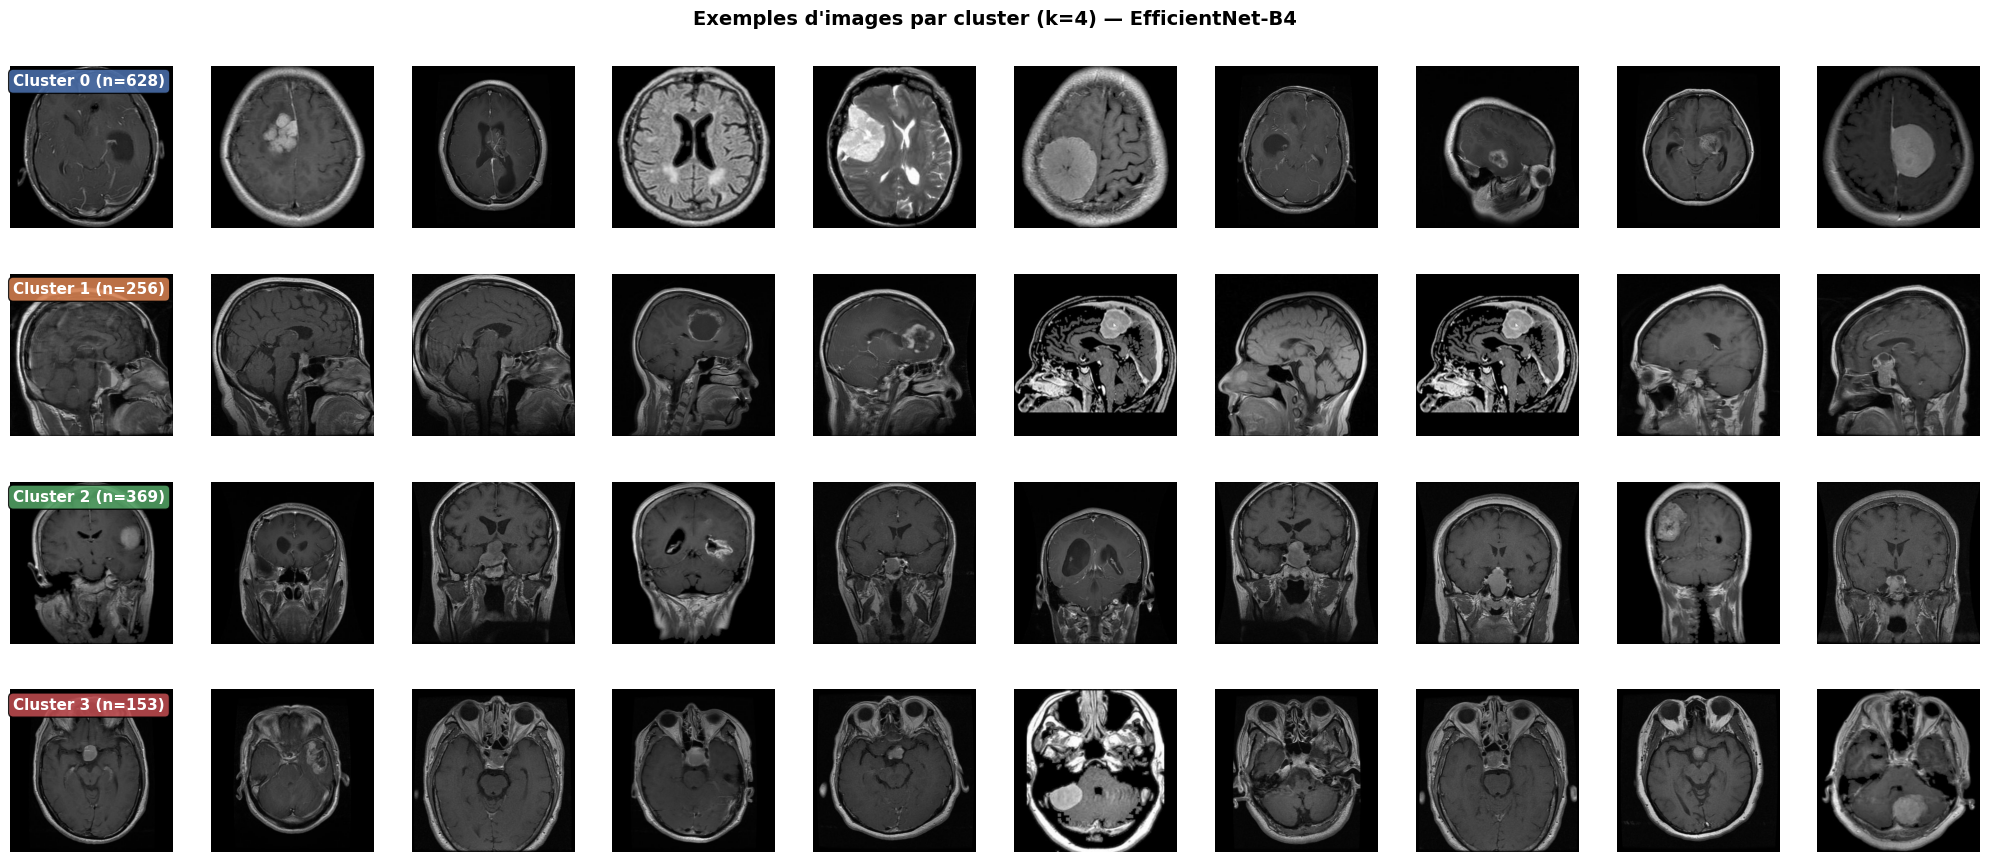

In [22]:
# ── 10 images par cluster (k=4) ───────────────────────────────────────────
n_samples = 10
clusters_4 = sorted(CLUSTER_COLORS_4.keys())

fig, axes = plt.subplots(len(clusters_4), n_samples, figsize=(20, 9))
fig.suptitle(f"Exemples d'images par cluster (k=4) — {modele}", fontsize=14, fontweight="bold")

for row_idx, cluster_id in enumerate(clusters_4):
    available = train_df[train_df["cluster4"] == cluster_id]["image_path"]
    sample_paths = available.sample(min(n_samples, len(available)), random_state=21).tolist()
    for col_idx in range(n_samples):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_paths):
            with Image.open(sample_paths[col_idx]) as img:
                ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id} (n={(train_df['cluster4'] == cluster_id).sum()})",
        transform=axes[row_idx][0].transAxes,
        fontsize=11, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS_4[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

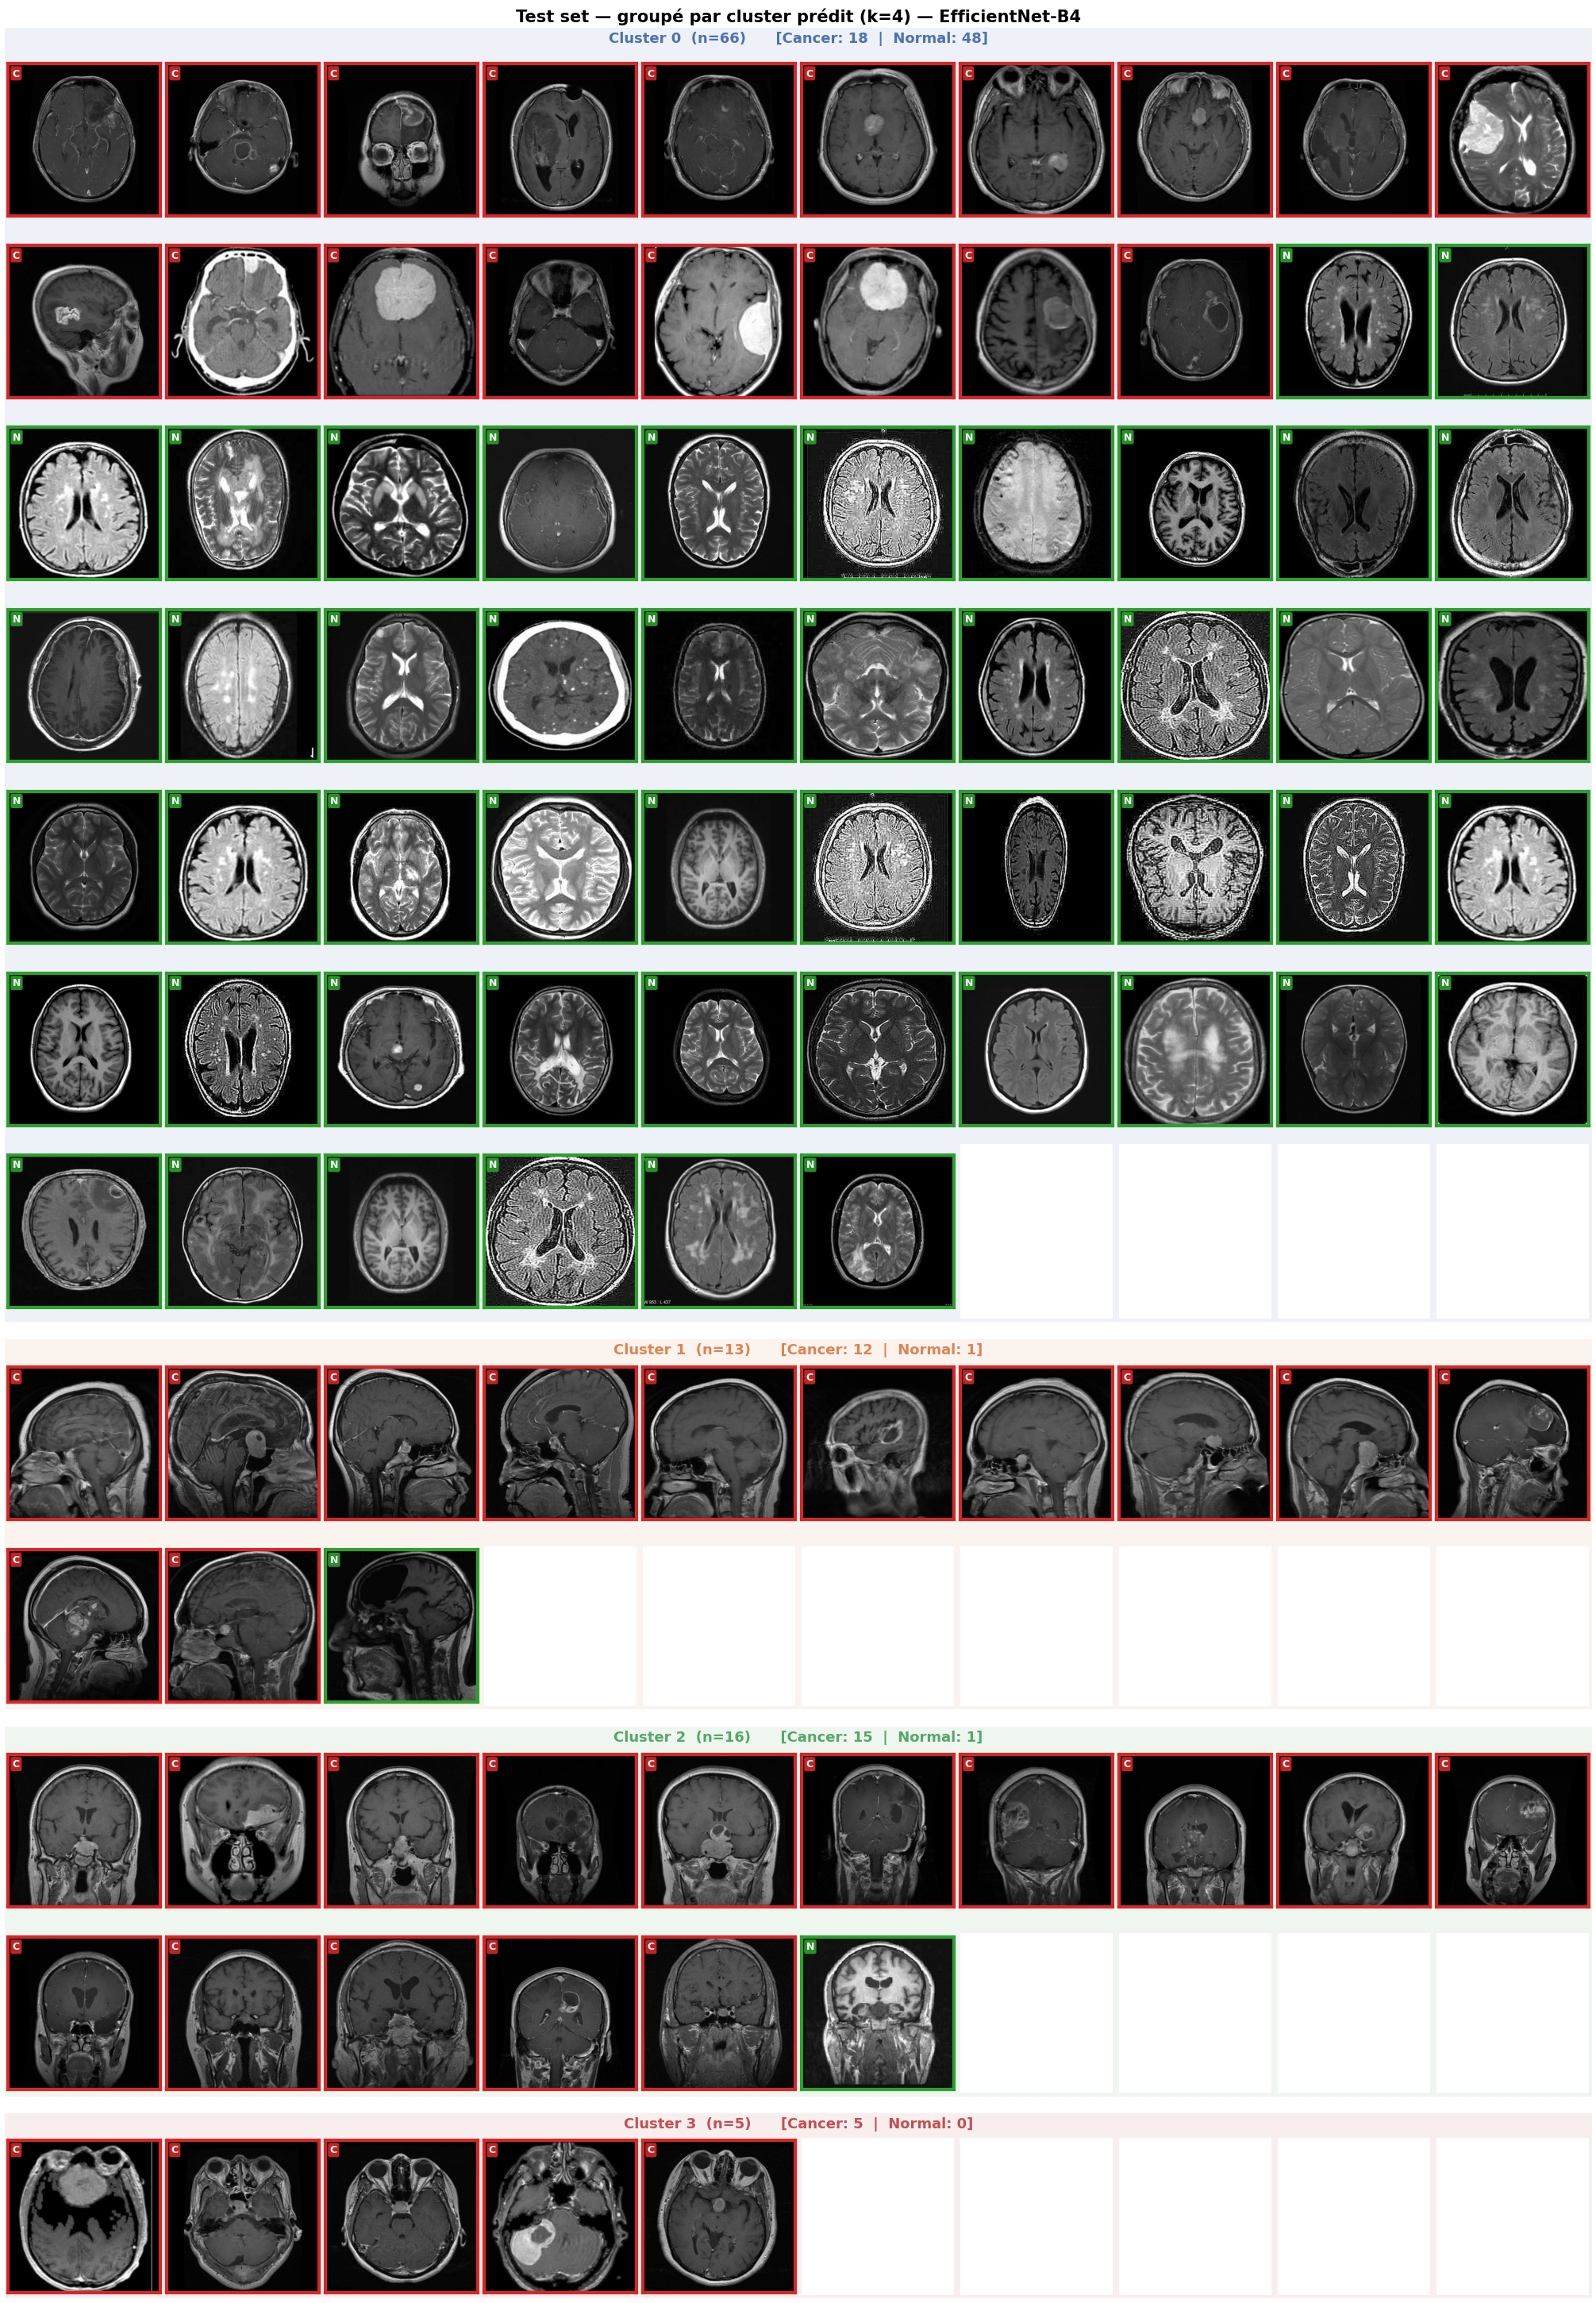

In [23]:
# ── Test set : groupé par cluster prédit (k=4) + bordure par vraie classe ──
LABEL_COLORS = {0: "#2CA02C", 1: "#D62728"}  # vert=normal, rouge=cancer
LABEL_NAMES  = {0: "Normal", 1: "Cancer"}
LABEL_BADGE  = {0: "N", 1: "C"}

# Prédiction des clusters k=4 sur le test set (sans muter test_df)
X_test_features = test_df.drop(columns=["label", "image_path"])
X_test_scaled_t = pd.DataFrame(scaler.transform(X_test_features), columns=X.columns)
X_test_pca_t    = pcamodel.transform(X_test_scaled_t)
test_cluster4   = gmm4.predict(X_test_pca_t)

y_test     = test_df["label"].values
paths_test = test_df["image_path"].values

n_cols = 10
clusters_order = sorted(CLUSTER_COLORS_4.keys())

# Hauteur dynamique : nb lignes par cluster
rows_per_cluster = {
    cid: max(1, -(-int((test_cluster4 == cid).sum()) // n_cols))
    for cid in clusters_order
}
total_rows = sum(rows_per_cluster.values())
fig_h = total_rows * 2.2 + 2.5

fig = plt.figure(figsize=(20, fig_h), constrained_layout=True)
fig.suptitle(
    f"Test set — groupé par cluster prédit (k=4) — {modele}",
    fontsize=15, fontweight="bold",
)
subfigs = fig.subfigures(
    len(clusters_order), 1, hspace=0.03,
    height_ratios=[rows_per_cluster[c] for c in clusters_order],
)

for subfig, cid in zip(subfigs, clusters_order):
    mask   = test_cluster4 == cid
    paths  = paths_test[mask]
    labels = y_test[mask]
    n      = len(paths)
    n_rows = rows_per_cluster[cid]

    # Distribution Cancer/Normal dans ce cluster
    n_cancer = int((labels == 1).sum())
    n_normal = int((labels == 0).sum())
    subfig.suptitle(
        f"Cluster {cid}  (n={n})      [Cancer: {n_cancer}  |  Normal: {n_normal}]",
        fontsize=13, fontweight="bold", color=CLUSTER_COLORS_4[cid],
    )
    subfig.set_facecolor(CLUSTER_COLORS_4[cid] + "18")

    axes = subfig.subplots(n_rows, n_cols)
    axes = np.atleast_2d(axes)
    for idx, ax in enumerate(axes.flat):
        if idx < n:
            lbl = int(labels[idx])
            color = LABEL_COLORS[lbl]
            try:
                with Image.open(paths[idx]) as img:
                    ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            # Bordure colorée = vraie classe
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
            # Badge C/N
            ax.text(
                0.03, 0.97, LABEL_BADGE[lbl],
                transform=ax.transAxes,
                fontsize=9, fontweight="bold", color="white",
                va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.9, edgecolor="none"),
            )
        else:
            for spine in ax.spines.values():
                spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

In [24]:
# ── Diagnostic : pourquoi le test collapse sur un cluster ? ──────────────
proba_test  = gmm4.predict_proba(X_test_pca_t)
proba_train = gmm4.predict_proba(X_pca)

print("Distribution train  :", np.bincount(gmm4.predict(X_pca), minlength=4))
print("Distribution test   :", np.bincount(test_cluster4, minlength=4))
print("Poids GMM (train)   :", gmm4.weights_.round(3))

print(f"\nLog-likelihood moyenne par point :")
print(f"  train : {gmm4.score_samples(X_pca).mean():.1f}")
print(f"  test  : {gmm4.score_samples(X_test_pca_t).mean():.1f}  (si très << train → overfit / shift)")

print(f"\nConfidence (max proba) :")
print(f"  train : min={proba_train.max(axis=1).min():.3f}  median={np.median(proba_train.max(axis=1)):.3f}")
print(f"  test  : min={proba_test.max(axis=1).min():.3f}   median={np.median(proba_test.max(axis=1)):.3f}")

print(f"\nCovariances par cluster (logdet grand + trace grande = composante 'fourre-tout') :")
print(f"  {'cluster':<8} {'weight':>7} {'logdet':>10} {'trace':>12}")
cov_type = gmm4.covariance_type
for i in range(4):
    cov_i = gmm4.covariances_[i]
    if cov_type == "full":
        _, logdet = np.linalg.slogdet(cov_i)
        trace = np.trace(cov_i)
    elif cov_type == "diag":
        logdet = np.log(cov_i).sum()
        trace = cov_i.sum()
    elif cov_type == "tied":
        _, logdet = np.linalg.slogdet(gmm4.covariances_)
        trace = np.trace(gmm4.covariances_)
    else:  # spherical
        d = X_pca.shape[1]
        logdet = d * np.log(cov_i)
        trace = d * cov_i
    print(f"  C{i:<7} {gmm4.weights_[i]:>7.3f} {logdet:>10.1f} {trace:>12.1f}")

print(f"\nIter pour converger : {gmm4.n_iter_}  (<5 = solution dégénérée probable)")
print(f"Covariance type     : {cov_type}")

Distribution train  : [628 256 369 153]
Distribution test   : [66 13 16  5]
Poids GMM (train)   : [0.447 0.182 0.262 0.109]

Log-likelihood moyenne par point :
  train : -607.1
  test  : -583.4  (si très << train → overfit / shift)

Confidence (max proba) :
  train : min=0.805  median=1.000
  test  : min=0.839   median=1.000

Covariances par cluster (logdet grand + trace grande = composante 'fourre-tout') :
  cluster   weight     logdet        trace
  C0         0.447      140.0       1364.1
  C1         0.182      140.0       1364.1
  C2         0.262      140.0       1364.1
  C3         0.109      140.0       1364.1

Iter pour converger : 6  (<5 = solution dégénérée probable)
Covariance type     : tied


# SCORES

Mapping : cluster 0 → normal  |  clusters 1, 2, 3 → cancer

  Accuracy   : 0.8000
  Precision  : 0.9412  (cancer=positif)
  Recall     : 0.6400  (cancer=positif)
  F1-score   : 0.7619
  F2-score   : 0.6838  (recall x2)
  ARI        : 0.3541

              precision    recall  f1-score   support

      Normal       0.73      0.96      0.83        50
      Cancer       0.94      0.64      0.76        50

    accuracy                           0.80       100
   macro avg       0.83      0.80      0.79       100
weighted avg       0.83      0.80      0.79       100

Composition de chaque cluster sur le test set :
  cluster       n   Normal   Cancer  →  prédit
  C0           66       48       18  →  Normal
  C1           13        1       12  →  Cancer
  C2           16        1       15  →  Cancer
  C3            5        0        5  →  Cancer


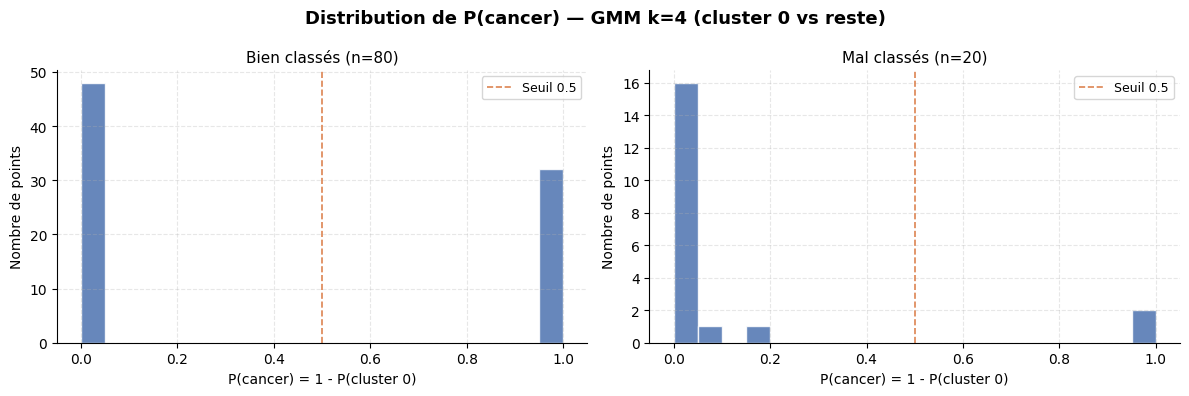

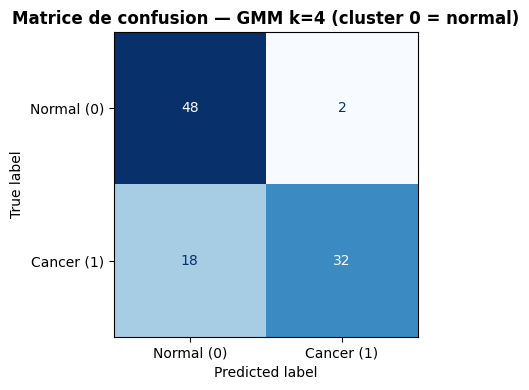

In [25]:
# ── SCORES k=4 avec mapping {0 → normal, 1/2/3 → cancer} ──────────────────
# Hypothèse : cluster 0 = classe majoritaire "normal", les 3 autres clusters = "cancer"
y_true_4       = test_df["label"].values  # 0=normal, 1=cancer
aligned_pred_4 = (test_cluster4 != 0).astype(int)

# P(cancer) = 1 - P(cluster 0)
proba_4_all     = gmm4.predict_proba(X_test_pca_t)
proba_cancer_4  = 1.0 - proba_4_all[:, 0]

ari_4 = adjusted_rand_score(y_true_4, aligned_pred_4)

print("Mapping : cluster 0 → normal  |  clusters 1, 2, 3 → cancer\n")
print("=" * 45)
print(f"  Accuracy   : {accuracy_score(y_true_4, aligned_pred_4):.4f}")
print(f"  Precision  : {precision_score(y_true_4, aligned_pred_4):.4f}  (cancer=positif)")
print(f"  Recall     : {recall_score(y_true_4, aligned_pred_4):.4f}  (cancer=positif)")
print(f"  F1-score   : {f1_score(y_true_4, aligned_pred_4):.4f}")
print(f"  F2-score   : {fbeta_score(y_true_4, aligned_pred_4, beta=2):.4f}  (recall x2)")
print(f"  ARI        : {ari_4:.4f}")
print("=" * 45)
print()
print(classification_report(y_true_4, aligned_pred_4, target_names=["Normal", "Cancer"]))

# ── Composition réelle de chaque cluster (test) ───────────────────────────
print("Composition de chaque cluster sur le test set :")
print(f"  {'cluster':<10} {'n':>4} {'Normal':>8} {'Cancer':>8}  →  prédit")
for c in range(4):
    mask = test_cluster4 == c
    n_c = int(mask.sum())
    n_normal = int(((y_true_4 == 0) & mask).sum())
    n_cancer = int(((y_true_4 == 1) & mask).sum())
    predicted = "Normal" if c == 0 else "Cancer"
    print(f"  C{c:<9} {n_c:>4} {n_normal:>8} {n_cancer:>8}  →  {predicted}")

# ── Distribution des probabilités — bien vs mal classés ───────────────────
correct_mask_4 = aligned_pred_4 == y_true_4
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de P(cancer) — GMM k=4 (cluster 0 vs reste)", fontsize=13, fontweight="bold")

for ax, (label, mask) in zip(axes, [("Bien classés", correct_mask_4), ("Mal classés", ~correct_mask_4)]):
    n = int(mask.sum())
    ax.hist(proba_cancer_4[mask], bins=20, range=(0, 1), color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="#DD8452", linestyle="--", linewidth=1.2, label="Seuil 0.5")
    ax.set_title(f"{label} (n={n})", fontsize=11)
    ax.set_xlabel("P(cancer) = 1 - P(cluster 0)", fontsize=10)
    ax.set_ylabel("Nombre de points", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# ── Matrice de confusion ───────────────────────────────────────────────────
cm_4 = confusion_matrix(y_true_4, aligned_pred_4)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=["Normal (0)", "Cancer (1)"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matrice de confusion — GMM k=4 (cluster 0 = normal)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

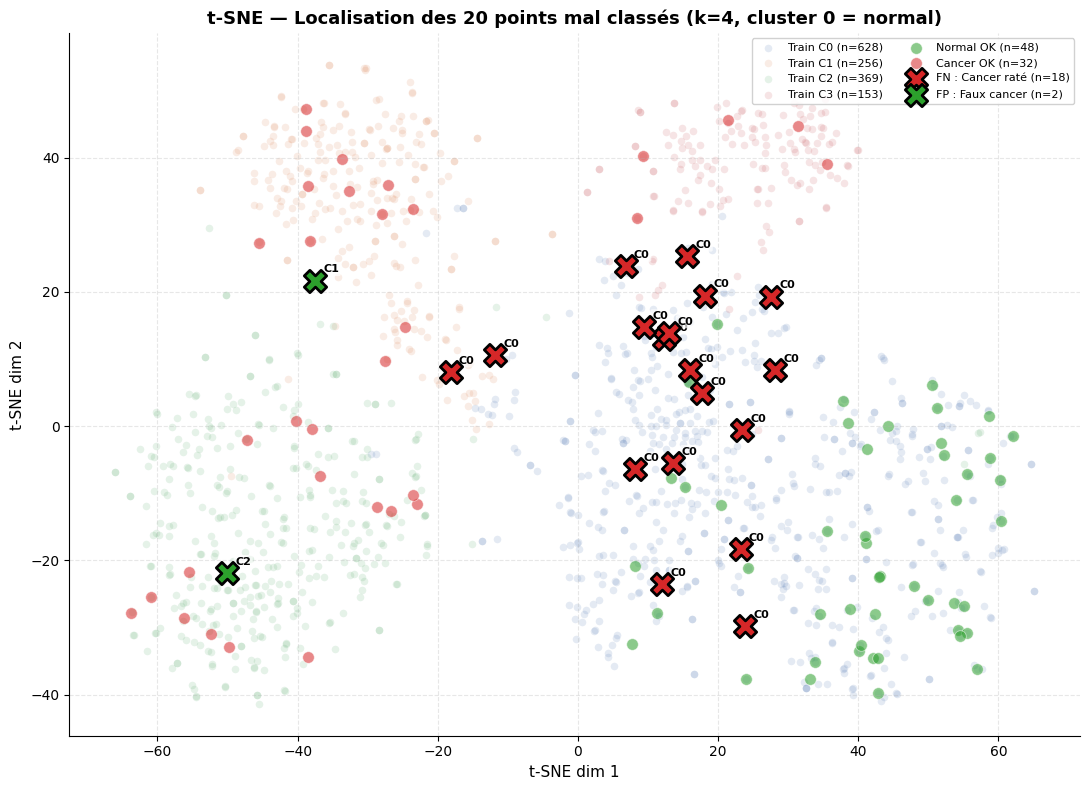

Total mal classés : 20
  FN (Cancer prédit Normal, C0)      : 18
  FP (Normal prédit Cancer, C1/C2/C3) : 2

Décomposition par cluster prédit :
  C0 : 18/66 mal classés  (27%)
  C1 : 1/13 mal classés  (8%)
  C2 : 1/16 mal classés  (6%)
  C3 : 0/5 mal classés  (0%)


In [26]:
# ── Localisation des points mal classés dans la t-SNE ────────────────────
# Nécessite que la cellule t-SNE combinée (91757e5e) ait été exécutée → X_tsne_test
wrong_mask_4 = ~correct_mask_4
n_wrong      = int(wrong_mask_4.sum())

# Type d'erreur : FN = cancer raté (prédit normal), FP = normal faux positif (prédit cancer)
fn_mask = wrong_mask_4 & (y_true_4 == 1)   # vrai=Cancer, prédit=Normal → raté
fp_mask = wrong_mask_4 & (y_true_4 == 0)   # vrai=Normal, prédit=Cancer → fausse alerte

fig, ax = plt.subplots(figsize=(11, 8))

# Fond : train (gris) + clusters k=4 pour donner le contexte
for cid, color in CLUSTER_COLORS_4.items():
    mask = cluster_labels_4 == cid
    ax.scatter(
        X_tsne_train[mask, 0], X_tsne_train[mask, 1],
        c=color, alpha=0.15, s=30, linewidths=0,
        label=f"Train C{cid} (n={mask.sum()})",
    )

# Test bien classés : petits points vert/rouge selon vraie classe
for lbl, color, name in [(0, "#2CA02C", "Normal OK"), (1, "#D62728", "Cancer OK")]:
    mask = correct_mask_4 & (y_true_4 == lbl)
    ax.scatter(
        X_tsne_test[mask, 0], X_tsne_test[mask, 1],
        c=color, alpha=0.55, s=70, linewidths=0.6, edgecolors="white",
        label=f"{name} (n={mask.sum()})",
    )

# Mal classés : gros X marqués, couleur = vraie classe
ax.scatter(
    X_tsne_test[fn_mask, 0], X_tsne_test[fn_mask, 1],
    c="#D62728", marker="X", s=260, linewidths=2.0, edgecolors="black",
    label=f"FN : Cancer raté (n={fn_mask.sum()})",
    zorder=5,
)
ax.scatter(
    X_tsne_test[fp_mask, 0], X_tsne_test[fp_mask, 1],
    c="#2CA02C", marker="X", s=260, linewidths=2.0, edgecolors="black",
    label=f"FP : Faux cancer (n={fp_mask.sum()})",
    zorder=5,
)

# Annoter chaque erreur avec le cluster prédit (C0..C3)
for i in np.where(wrong_mask_4)[0]:
    ax.annotate(
        f"C{test_cluster4[i]}",
        (X_tsne_test[i, 0], X_tsne_test[i, 1]),
        xytext=(6, 6), textcoords="offset points",
        fontsize=8, fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.7, edgecolor="none"),
    )

ax.set_title(
    f"t-SNE — Localisation des {n_wrong} points mal classés (k=4, cluster 0 = normal)",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(loc="best", fontsize=8, ncol=2, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Récapitulatif tabulaire
print(f"Total mal classés : {n_wrong}")
print(f"  FN (Cancer prédit Normal, C0)      : {fn_mask.sum()}")
print(f"  FP (Normal prédit Cancer, C1/C2/C3) : {fp_mask.sum()}")
print(f"\nDécomposition par cluster prédit :")
for c in range(4):
    in_c  = test_cluster4 == c
    wrong = (wrong_mask_4 & in_c).sum()
    total = in_c.sum()
    if total > 0:
        print(f"  C{c} : {wrong}/{total} mal classés  ({wrong/total:.0%})")

# Optimisation via RF

In [27]:
# ── RF OOF calibré : confiance dans les pseudo-labels k=4 ─────────────────
# cross_val_predict → probas OOF vraies (chaque point prédit par un modèle
#   qui ne l'a jamais vu à l'entraînement).
# CalibratedClassifierCV(method='sigmoid') → Platt scaling OvR :
#   corrige le biais RF (probas trop concentrées autour de 0.5 ou 1.0 selon
#   le déséquilibre) → les seuils 0.7 / 0.8 deviennent interprétables.
# Outer 5-fold StratifiedKFold × inner 3-fold calibration = 15 fits.
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

base_rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 12,
    min_samples_leaf = 5,
    class_weight     = "balanced",   # C3=152 vs C0=631 : critique
    random_state     = 42,
)

calibrated_rf = CalibratedClassifierCV(
    estimator = base_rf,
    method    = "sigmoid",  # Platt scaling : robuste sur petits effectifs par classe
    cv        = 3,          # inner CV de calibration sur le fold train
    n_jobs    = -1,
)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dataset       : {X_pca.shape[0]} pts × {X_pca.shape[1]} features")
print(f"Estimateur    : RF(500 arbres, max_depth=12, min_samples_leaf=5, balanced)")
print(f"Calibration   : Platt sigmoid, inner cv=3")
print(f"OOF           : StratifiedKFold outer cv=5")
print(f"Total fits    : 5 × 3 = 15  (peut prendre 1-3 min)\n")

proba_oof = cross_val_predict(
    calibrated_rf,
    X_pca,
    cluster_labels_4,
    cv     = outer_cv,
    method = "predict_proba",
)

# Sanity checks
assert np.allclose(proba_oof.sum(axis=1), 1.0, atol=1e-6), "Probas OOF ne somment pas à 1"
assert 0 not in proba_oof.shape, "proba_oof vide"

confidence_oof = proba_oof[np.arange(len(X_pca)), cluster_labels_4]
oof_acc        = (proba_oof.argmax(axis=1) == cluster_labels_4).mean()

print(f"Accuracy OOF  : {oof_acc:.3f}")
print(f"  (> 0.90 = clusters très séparés | 0.65-0.85 = frontières floues)\n")

print("Distribution de la confidence OOF calibrée :")
for p in [0, 10, 25, 50, 75, 90, 95, 100]:
    print(f"  p{p:>3} : {np.percentile(confidence_oof, p):.3f}")

Dataset       : 1406 pts × 379 features
Estimateur    : RF(500 arbres, max_depth=12, min_samples_leaf=5, balanced)
Calibration   : Platt sigmoid, inner cv=3
OOF           : StratifiedKFold outer cv=5
Total fits    : 5 × 3 = 15  (peut prendre 1-3 min)

Accuracy OOF  : 0.971
  (> 0.90 = clusters très séparés | 0.65-0.85 = frontières floues)

Distribution de la confidence OOF calibrée :
  p  0 : 0.043
  p 10 : 0.804
  p 25 : 0.929
  p 50 : 0.971
  p 75 : 0.993
  p 90 : 0.997
  p 95 : 0.998
  p100 : 0.999


  Seuil   Gardés   % dataset   C0-Normal   C1+2+3-Cancer   % cancer gardé
---------------------------------------------------------------------------
  60%      1337       95.1%         609             728            54.5%
  70%      1318       93.7%         600             718            54.5%
  80%      1266       90.0%         582             684            54.0%
  90%      1162       82.6%         565             597            51.4%


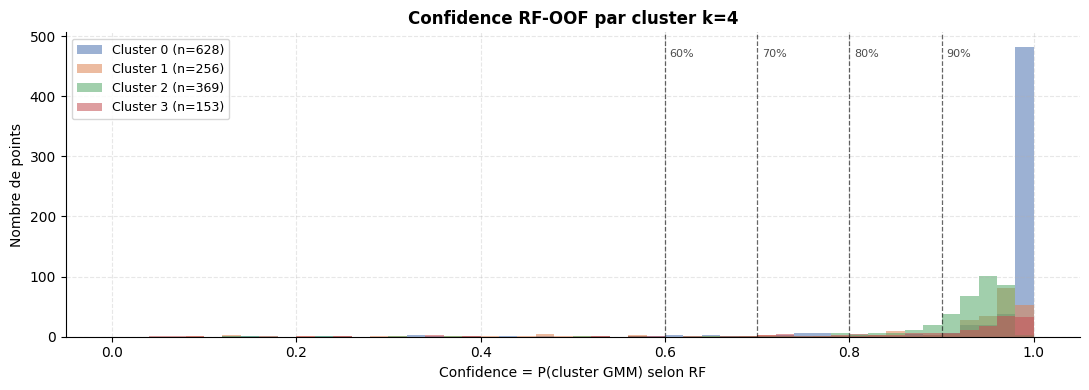

In [28]:
# ── Statistiques par seuil (60% → 90%, tous les 10%) ──────────────────────
thresholds = [0.60, 0.70, 0.80, 0.90]

print(f"{'Seuil':>7}  {'Gardés':>7}  {'% dataset':>10}  {'C0-Normal':>10}  {'C1+2+3-Cancer':>14}  {'% cancer gardé':>15}")
print("-" * 75)
for t in thresholds:
    m = confidence_oof >= t
    n_k     = int(m.sum())
    n_nor   = int(((cluster_labels_4 == 0) & m).sum())
    n_can   = int(((cluster_labels_4 != 0) & m).sum())
    pct_can = n_can / n_k if n_k > 0 else 0
    print(f"  {t:.0%}   {n_k:>7}  {n_k/len(X_pca):>10.1%}  {n_nor:>10}  {n_can:>14}  {pct_can:>15.1%}")

# Histogramme de la confidence par cluster
fig, ax = plt.subplots(figsize=(11, 4))
for cid, color in CLUSTER_COLORS_4.items():
    ax.hist(
        confidence_oof[cluster_labels_4 == cid], bins=50, range=(0, 1),
        color=color, alpha=0.55, label=f"Cluster {cid} (n={(cluster_labels_4==cid).sum()})",
        edgecolor="none",
    )
for t in thresholds:
    ax.axvline(t, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
    ax.text(t + 0.005, ax.get_ylim()[1] * 0.92, f"{t:.0%}", fontsize=8, color="black", alpha=0.7)

ax.set_title("Confidence RF-OOF par cluster k=4", fontsize=12, fontweight="bold")
ax.set_xlabel("Confidence = P(cluster GMM) selon RF", fontsize=10)
ax.set_ylabel("Nombre de points", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [29]:
# ── Choix du seuil et filtrage ─────────────────────────────────────────────
# Modifier THRESHOLD après avoir lu le tableau ci-dessus
THRESHOLD = 0.85   # ← 0.60 / 0.70 / 0.80 / 0.90

clean_mask           = confidence_oof >= THRESHOLD
X_pca_clean          = X_pca[clean_mask]
cluster_labels_clean = cluster_labels_4[clean_mask]
train_df_clean       = train_df.iloc[clean_mask].copy()
train_df_clean["pseudo_label"] = (cluster_labels_clean != 0).astype(int)

n_total  = len(X_pca)
n_kept   = int(clean_mask.sum())
n_reject = n_total - n_kept
n_normal = int(((cluster_labels_4 == 0) & clean_mask).sum())
n_cancer = int(((cluster_labels_4 != 0) & clean_mask).sum())

print(f"Seuil retenu : {THRESHOLD:.0%}")
print(f"Points gardés : {n_kept} / {n_total}  ({n_kept/n_total:.1%})")
print(f"  C0 – Normal       : {n_normal}")
print(f"  C1+C2+C3 – Cancer : {n_cancer}")
print(f"Points rejetés : {n_reject}  ({n_reject/n_total:.1%})")
print()
print("Rejets par cluster :")
for c in range(4):
    n_tot_c = int((cluster_labels_4 == c).sum())
    n_rej_c = int(((~clean_mask) & (cluster_labels_4 == c)).sum())
    print(f"  C{c} : {n_rej_c}/{n_tot_c} rejetés  ({n_rej_c/n_tot_c:.0%})")

Seuil retenu : 85%
Points gardés : 1228 / 1406  (87.3%)
  C0 – Normal       : 574
  C1+C2+C3 – Cancer : 654
Points rejetés : 178  (12.7%)

Rejets par cluster :
  C0 : 54/628 rejetés  (9%)
  C1 : 47/256 rejetés  (18%)
  C2 : 39/369 rejetés  (11%)
  C3 : 38/153 rejetés  (25%)


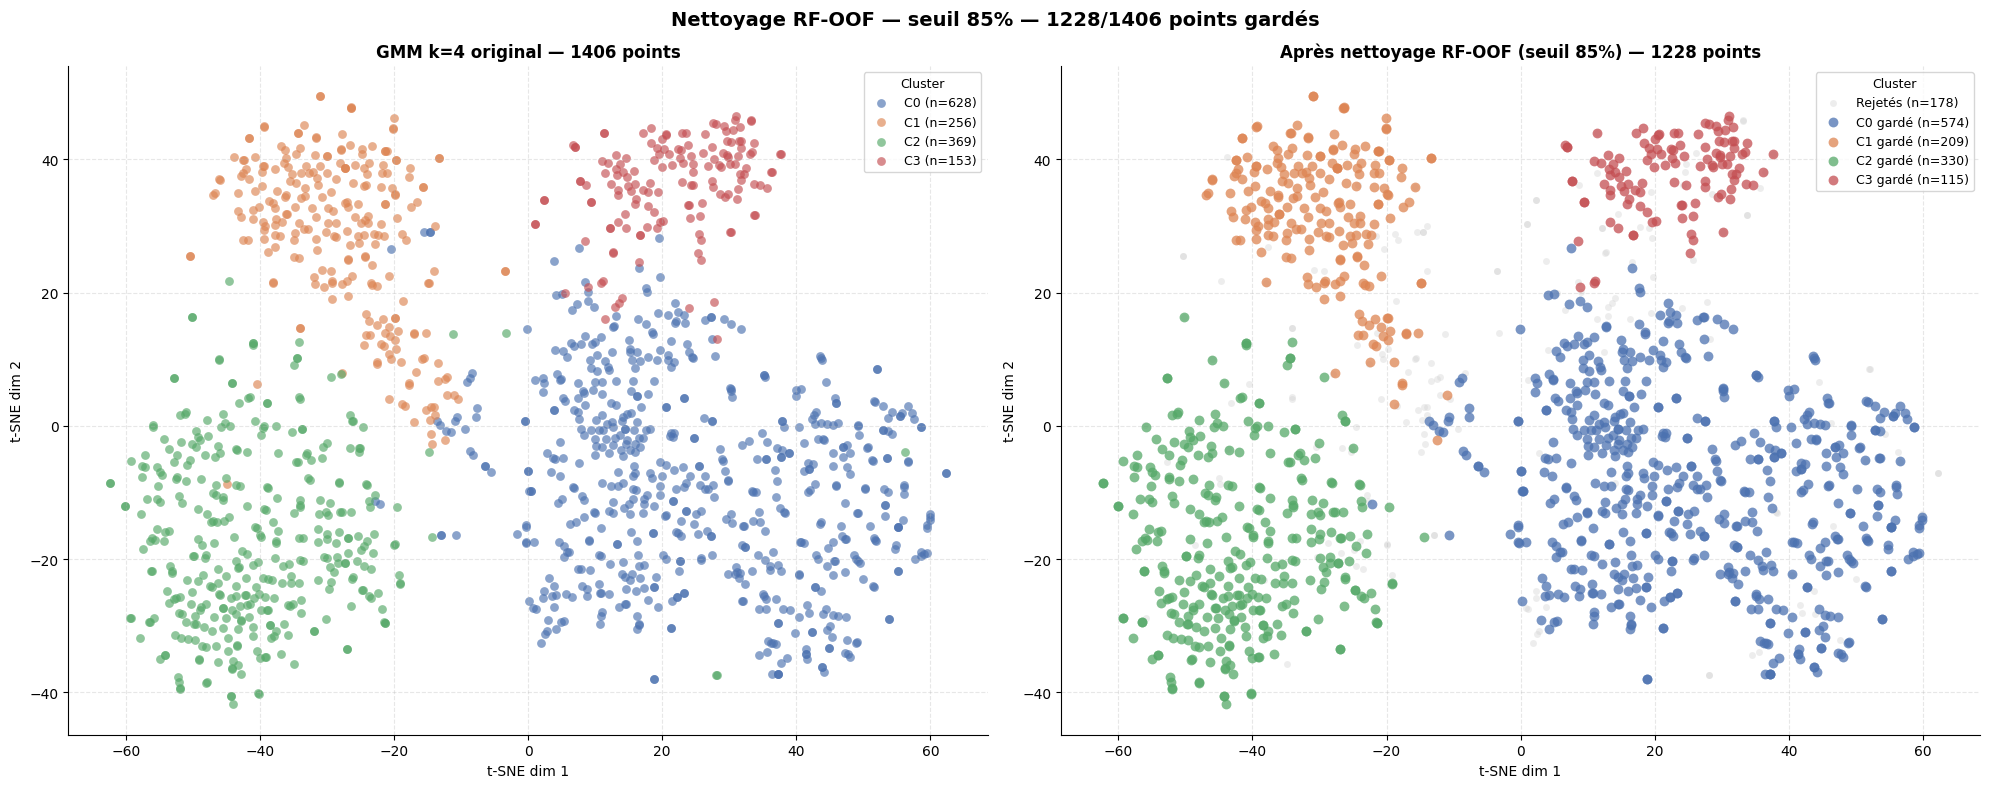

In [30]:
# ── t-SNE côte à côte : avant / après nettoyage RF-OOF ────────────────────
# Même espace t-SNE (X_tsne, train-only, 1406 points) pour comparaison directe.
# Gauche : tous les points k=4.
# Droite : points gardés (pleins) + points rejetés (gris clair, petits).
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    f"Nettoyage RF-OOF — seuil {THRESHOLD:.0%} — {n_kept}/{n_total} points gardés",
    fontsize=14, fontweight="bold",
)

# ── Panneau gauche : k=4 original ─────────────────────────────────────────
ax = axes[0]
for cid, color in CLUSTER_COLORS_4.items():
    mask = cluster_labels_4 == cid
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, alpha=0.65, s=40, linewidths=0,
        label=f"C{cid} (n={mask.sum()})",
    )
ax.set_title(f"GMM k=4 original — {n_total} points", fontsize=12, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=10)
ax.set_ylabel("t-SNE dim 2", fontsize=10)
ax.legend(title="Cluster", fontsize=9, title_fontsize=9, loc="best")
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=ax)

# ── Panneau droit : après filtrage ────────────────────────────────────────
ax = axes[1]

# Points rejetés en arrière-plan
ax.scatter(
    X_tsne[~clean_mask, 0], X_tsne[~clean_mask, 1],
    c="lightgray", alpha=0.4, s=25, linewidths=0,
    label=f"Rejetés (n={n_reject})",
    zorder=1,
)
# Points gardés, colorés par cluster
for cid, color in CLUSTER_COLORS_4.items():
    mask = (cluster_labels_4 == cid) & clean_mask
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, alpha=0.75, s=50, linewidths=0,
        label=f"C{cid} gardé (n={mask.sum()})",
        zorder=2,
    )

ax.set_title(
    f"Après nettoyage RF-OOF (seuil {THRESHOLD:.0%}) — {n_kept} points",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("t-SNE dim 1", fontsize=10)
ax.set_ylabel("t-SNE dim 2", fontsize=10)
ax.legend(title="Cluster", fontsize=9, title_fontsize=9, loc="best")
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Extractions

In [31]:
# ── Pseudo-labels GMM sur les 1406 images non labellisées ─────────────────
proba_train = gmm.predict_proba(X_pca)  # shape (1406, 2)

pseudo_df = pd.DataFrame({
    "image_path"   : train_df["image_path"].values,
    "label" : [1 if cluster_to_class[c] == "cancer" else 0 for c in cluster_labels],
    "proba_cancer" : proba_train[:, cancer_cluster].round(4),
    "proba_normal" : proba_train[:, 1 - cancer_cluster].round(4),
})

print(f"Total : {len(pseudo_df)} images")
print(f"  pseudo-cancer (1) : {(pseudo_df['label'] == 1).sum()}")
print(f"  pseudo-normal (0) : {(pseudo_df['label'] == 0).sum()}\n")

out_path = Path("pseudo_labels_gmm.csv")
pseudo_df.to_csv(out_path, index=False)
print(f"Sauvegardé → {out_path}")

pseudo_df.head(10)

NameError: name 'cluster_to_class' is not defined

In [ ]:
# ── Export pseudo-labels nettoyés (RF-OOF, seuil {THRESHOLD:.0%}) ─────────
# Mapping : cluster 0 → normal (0)  |  clusters 1, 2, 3 → cancer (1)
# Seuls les {n_kept} points ayant confidence_oof >= THRESHOLD sont exportés.
pseudo_v4_df = pd.DataFrame({
    "image_path"      : train_df_clean["image_path"].values,
    "label"           : (cluster_labels_clean != 0).astype(int),
    "cluster_k4"      : cluster_labels_clean,
    "confidence_oof"  : confidence_oof[clean_mask].round(4),
    "proba_cancer"    : (1.0 - proba_oof[clean_mask, 0]).round(4),
    "proba_normal"    : proba_oof[clean_mask, 0].round(4),
})

print(f"Seuil RF-OOF   : {THRESHOLD:.0%}")
print(f"Total exporté  : {len(pseudo_v4_df)} / {len(X_pca)} images ({len(pseudo_v4_df)/len(X_pca):.1%})")
print(f"  pseudo-cancer (1) : {(pseudo_v4_df['label'] == 1).sum()}")
print(f"  pseudo-normal (0) : {(pseudo_v4_df['label'] == 0).sum()}\n")

out_path_v4 = Path("pseudo_labels_gmm_v4.csv")
pseudo_v4_df.to_csv(out_path_v4, index=False)
print(f"Sauvegardé → {out_path_v4}")

pseudo_v4_df.head(10)

Seuil RF-OOF   : 85%
Total exporté  : 1225 / 1406 images (87.1%)
  pseudo-cancer (1) : 648
  pseudo-normal (0) : 577

Sauvegardé → pseudo_labels_gmm_v4.csv


,image_path,label,cluster_k4,confidence_oof,proba_cancer,proba_normal
0,data\sans_label\001b158a-7af8-451e-bf31-3a9116...,1,1,0.9797,0.9895,0.0105
1,data\sans_label\00366e8d-5520-4d3c-a70b-91a7ee...,0,0,0.9798,0.0202,0.9798
2,data\sans_label\00455a62-f79f-4072-9a23-4951e7...,0,0,0.9974,0.0026,0.9974
3,data\sans_label\005d9a37-8894-4eb5-8367-1015d4...,1,2,0.9145,0.9498,0.0502
4,data\sans_label\009e9d31-9f37-4d97-a941-815012...,1,2,0.9591,0.9768,0.0232
5,data\sans_label\009eac4a-c951-4da9-852a-b32e9c...,1,3,0.9827,0.9918,0.0082
6,data\sans_label\00e9e198-79de-47ab-9f4e-7b7615...,1,1,0.9864,0.9962,0.0038
7,data\sans_label\01d1f0ed-5070-45a8-ad26-f8a95e...,0,0,0.9915,0.0085,0.9915
8,data\sans_label\01d4471e-7c83-4335-ab49-c650d0...,1,2,0.9571,0.9734,0.0266
9,data\sans_label\01e09766-fcd9-4df0-82f7-265f9f...,1,2,0.9649,0.9756,0.0244


In [ ]:
# ── Test set avec vrais labels ─────────────────────────────────────────────
test_export_df = pd.DataFrame({
    "image_path"   : test_df["image_path"].values,
    "label" : test_df["label"].values,   # vrais labels : 1=cancer, 0=normal
    "proba_cancer" : proba_pred[:, cancer_cluster].round(4),
    "proba_normal" : proba_pred[:, 1 - cancer_cluster].round(4),
})

print(f"Total : {len(test_export_df)} images")
print(f"  cancer (1) : {(test_export_df['label'] == 1).sum()}")
print(f"  normal (0) : {(test_export_df['label'] == 0).sum()}\n")

out_path_test = Path("true_labels_test.csv")
test_export_df.to_csv(out_path_test, index=False)
print(f"Sauvegardé → {out_path_test}")

test_export_df.head(10)

Total : 100 images
  cancer (1) : 50
  normal (0) : 50

Sauvegardé → true_labels_test.csv


,image_path,label,proba_cancer,proba_normal
0,data\avec_labels\cancer\05340cd4-3bb2-459d-993...,1,1.0000,0.0000
1,data\avec_labels\cancer\0c6f3641-60d9-4a76-abe...,1,0.0000,1.0000
2,data\avec_labels\cancer\0f718241-8f63-4b55-81c...,1,0.0000,1.0000
3,data\avec_labels\cancer\11a7a426-4806-401e-98b...,1,1.0000,0.0000
4,data\avec_labels\cancer\1c043dbb-4623-4769-8e5...,1,1.0000,0.0000
5,data\avec_labels\cancer\27149ff6-8363-4942-a72...,1,1.0000,0.0000
6,data\avec_labels\cancer\2b810835-844c-49ff-b0f...,1,1.0000,0.0000
7,data\avec_labels\cancer\2d662cc1-509b-4657-a20...,1,0.9993,0.0007
8,data\avec_labels\cancer\2fa551e9-5b85-44f6-ab7...,1,1.0000,0.0000
9,data\avec_labels\cancer\3c3d07cb-ec2a-43b0-b8a...,1,0.0000,1.0000
